In [81]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd

In [13]:
G_nyc =ox.graph_from_place("New York, New York, US", network_type = "drive" )

In [14]:
G_nyc.number_of_nodes(), G_nyc.number_of_edges()

(55282, 139192)

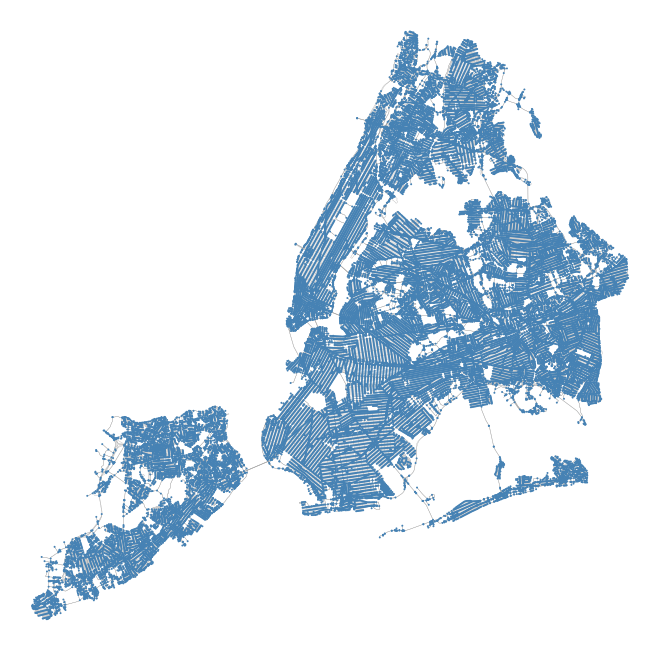

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [15]:
fig, ax = plt.subplots(1, 1, figsize = (4,4), dpi = 200)
ox.plot_graph(G_nyc, ax= ax, bgcolor='white', node_color= 'steelblue', node_size= 0.5, edge_linewidth= 0.1)

In [16]:
G_tompkins = ox.graph_from_place("Tompkins County, New York, USA", network_type = "drive")

In [17]:
G_tompkins.number_of_nodes(), G_tompkins.number_of_edges()

(3586, 9441)

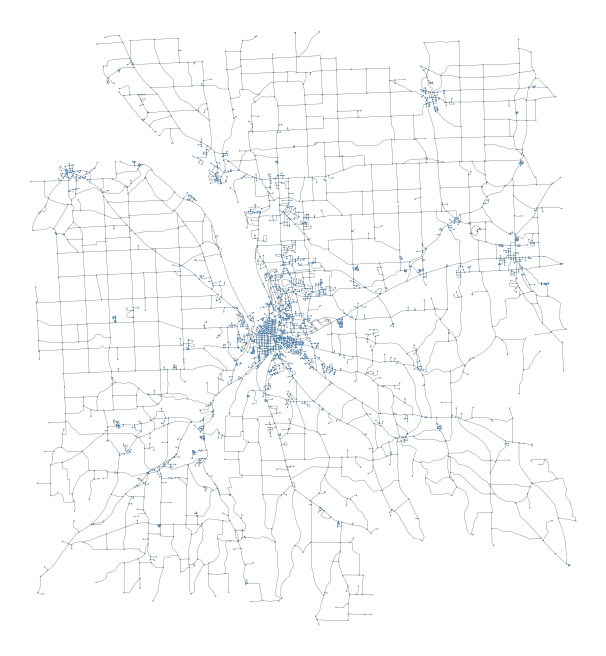

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [19]:
fig, ax = plt.subplots(1, 1, figsize = (4,4), dpi = 200)
ox.plot_graph(G_tompkins, ax = ax, bgcolor="white", node_color= "steelblue", node_size = 0.2, edge_linewidth=0.1)

In [71]:

tags = {"boundary": "administrative", "admin_level": "6"}
counties = ox.features_from_place("New York State, USA", tags = tags)

/Users/tedwhite15/miniforge3/lib/python3.12/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 87 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [73]:
#keep only polygons
counties = counties[counties.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

#Keep only named counties
counties = counties[counties["name"].notna()].copy()

#remove towns
counties = counties[counties["name"].str.endswith("County", na=False)].copy()


In [74]:
exclude = [
    "Addison County",
    "Bennington County",
    "Bergen County",
    "Berkshire County",
    "Bradford County",
    "Chittenden County",
    "Frontenac County",
    "Grand Isle County",
    "Hudson County",
    "McKean County",
    "Middlesex County",
    "Monmouth County",
    "Passaic County",
    "Pike County",
    "Potter County",
    "Prince Edward County",
    "Rutland County",
    "South County",
    "Susquehanna County",
    "Sussex County",
    "Union County"
]

counties = counties[
    ~counties["name"].isin(exclude)
].copy()

In [ ]:
counties = counties.drop_duplicates(subset="name")  # remove duplicate county names
counties = counties.reset_index(drop=True) # reindex after all the filtering

counties.shape

(62, 502)

In [77]:
counties.head()

,geometry,boundary,description,ele,name,wikidata,wikimedia_commons,admin_level,gnis:feature_id,nist:fips_code,...,name:etymology:wikipedia,phone,sidewalk:bicycle,is_in:iso_3166_2,check_date,contact:city,contact:pobox,contact:postcode,contact:state,email
0,"POLYGON ((-79.29797 42.69246, -79.29678 42.692...",administrative,NaN,NaN,Erie County,Q114843,NaN,6,NaN,36029,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"POLYGON ((-79.20067 43.45047, -78.69039 43.631...",administrative,NaN,NaN,Niagara County,Q114969,NaN,6,NaN,36063,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"POLYGON ((-78.46643 43.30277, -78.46632 43.313...",administrative,NaN,NaN,Orleans County,Q115125,NaN,6,NaN,36073,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"POLYGON ((-78.46543 43.12841, -78.46255 43.128...",administrative,NaN,NaN,Genesee County,Q115014,NaN,6,NaN,36037,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"POLYGON ((-79.06127 41.9995, -79.06096 42.0121...",administrative,NaN,NaN,Cattaraugus County,Q114923,NaN,6,NaN,36009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
#spatial join
county_gdf = counties[["name", "geometry"]].copy()
adj = gpd.sjoin(county_gdf, county_gdf, how="inner", predicate="touches", lsuffix = "left", rsuffix = "right")


#remove self matches
adj = adj[adj["name_left"] != adj["name_right"]]

In [82]:
#Build graph 
G = nx.Graph()

# add one node per county
for name in county_gdf["name"]:
    G.add_node(name)


#add edges
for _, row in adj.iterrows():
    G.add_edge(row["name_left"], row["name_right"])

In [83]:
G.number_of_nodes(), G.number_of_edges()

(62, 143)

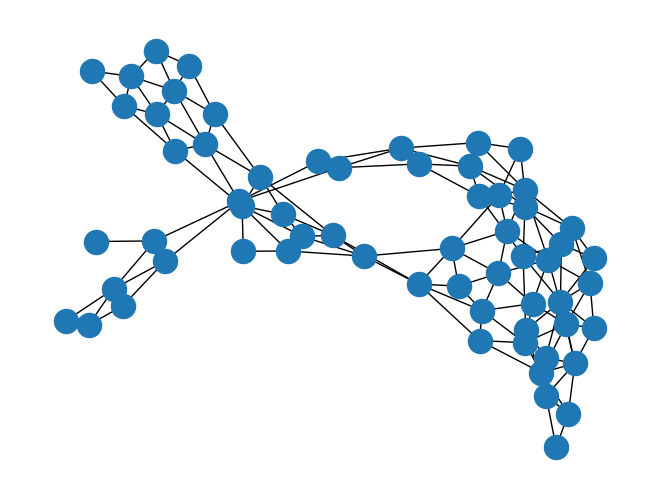

In [84]:
nx.draw(G)

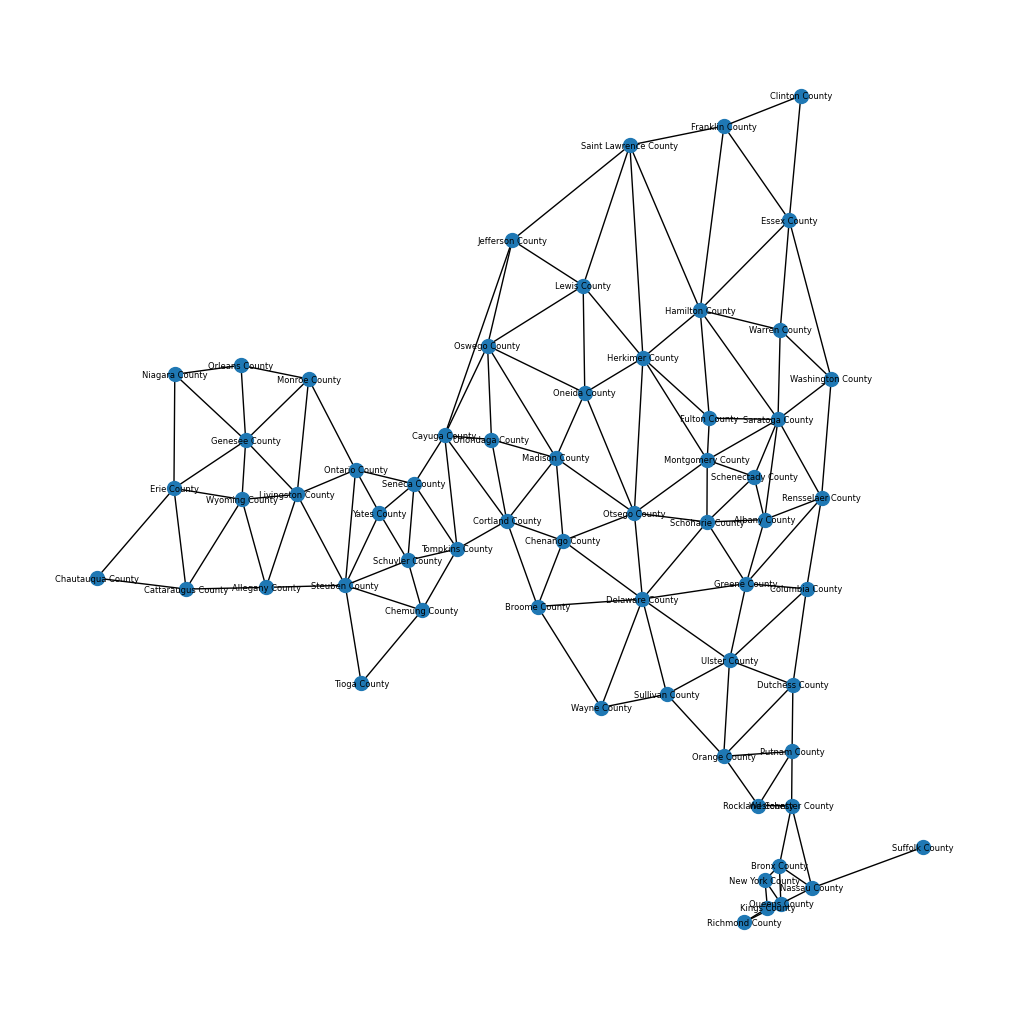

In [85]:
pos = {
    row["name"]: (row.geometry.centroid.x, row.geometry.centroid.y)
    for _, row in county_gdf.iterrows()
}

plt.figure(figsize=(10, 10))
nx.draw(
    G,
    pos=pos,
    with_labels=True,
    node_size=100,
    font_size=6
)
plt.show()